<a href="https://colab.research.google.com/github/thatvivekhingu/Machine_learning/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
df=pd.read_csv("insurance_data.csv")
df

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


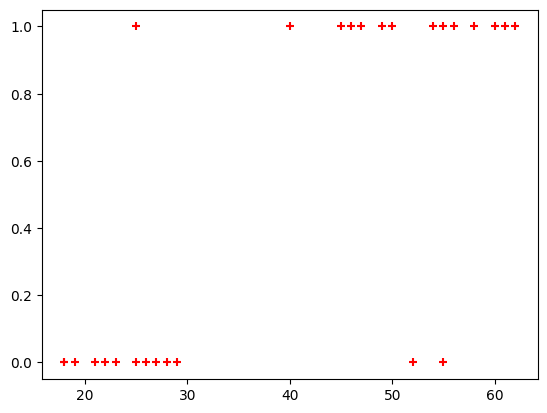

In [82]:
plt.scatter(df.age,df.bought_insurance,marker="+",color="red")

In [83]:
df.shape


(27, 2)

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,test_size=0.1)
 # 10% data randomly selected for the test
X_test


,age
11,28
5,56
18,19


In [86]:
##prediction our model

In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
model=LogisticRegression()

In [89]:
model.fit(X_train,y_train)

LogisticRegression()

In [90]:
model.predict(X_test)

array([0, 1, 0])

In [91]:
model.score(X_test,y_test)

1.0

In [92]:
model.predict_proba(X_test)

array([[0.78491352, 0.21508648],
       [0.09831539, 0.90168461],
       [0.91856041, 0.08143959]])

### Excercise

In [121]:
import seaborn as sns
data=pd.read_csv("HR_comma_sep.csv")
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [124]:
left=data[data.left==1]
left.shape

(3571, 10)

In [126]:
stay=data[data.left==0]
stay.shape

(11428, 10)

### Impact of salary on employee retention



<Axes: xlabel='salary'>

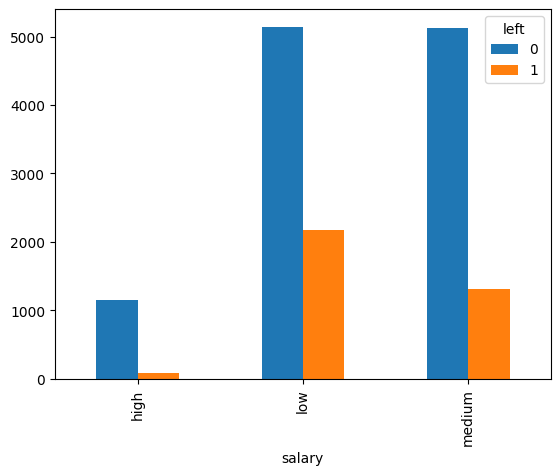

In [127]:
pd.crosstab(data.salary,data.left).plot(kind='bar')

### Department wise employee retention rate

<Axes: xlabel='Department'>

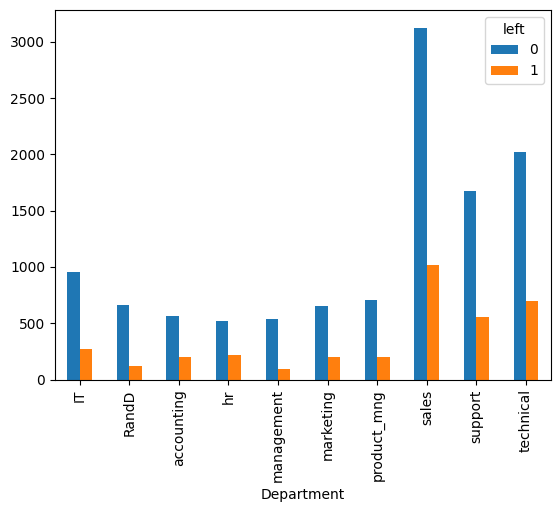

In [129]:
pd.crosstab(data.Department,data.left).plot(kind='bar')



In [131]:
#From the data analysis so far we can conclude that we will use following variables as independant variables in our model
# **Satisfaction Level**
# **Average Monthly Hours**
# **Promotion Last 5 Years**
# **Salary**

In [133]:
subdf = data[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
subdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [134]:
#salary dummy variable

In [136]:
salary_dummies = pd.get_dummies(subdf.salary, prefix="salary")

In [137]:
df_with_dummies = pd.concat([subdf,salary_dummies],axis='columns')

In [138]:
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [139]:
df_with_dummies.drop('salary',axis='columns',inplace=True)
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False
